In [31]:
# CELL 1 — imports
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [32]:
# CELL 2 — load data (ONLY ONCE)
train_df = pd.read_csv("train_split.csv")
test_df = pd.read_csv("test_split (1).csv")

In [33]:
# CELL 3 — preprocessing (ONLY ONCE, before any model)
train_clean = train_df.drop(columns=["id"])
test_clean = test_df.drop(columns=["id"])

# drop the 1 row with missing Response in test set — do this ONCE, here
test_clean = test_clean.dropna(subset=["Response"])

cat_cols = ["Gender", "Vehicle_Age", "Vehicle_Damage"]
for col in cat_cols:
    le = LabelEncoder()
    train_clean[col] = le.fit_transform(train_clean[col])
    test_clean[col] = le.transform(test_clean[col])

X_train = train_clean.drop(columns=["Response"])
y_train = train_clean["Response"]
X_test = test_clean.drop(columns=["Response"])
y_test = test_clean["Response"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
test_clean = test_clean.dropna(subset=["Response"])

In [35]:
# CELL 4 — results tracker + evaluate function (ONLY ONCE)

results = []

def evaluate_model(name, y_test, y_pred, y_prob=None):
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
    }
    results.append(metrics)
    print(f"{name}: {metrics}")
    return metrics

In [36]:
log_model = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Logistic Regression", y_test, log_pred, log_prob)

Logistic Regression: {'Model': 'Logistic Regression', 'Accuracy': 0.64456474871844, 'Precision': 0.2510179153094462, 'Recall': 0.9758607043925603, 'F1-Score': 0.39931989312606264, 'ROC-AUC': np.float64(0.8238953241544249)}


{'Model': 'Logistic Regression',
 'Accuracy': 0.64456474871844,
 'Precision': 0.2510179153094462,
 'Recall': 0.9758607043925603,
 'F1-Score': 0.39931989312606264,
 'ROC-AUC': np.float64(0.8238953241544249)}

In [37]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

evaluate_model("Decision Tree", y_test, dt_pred, dt_prob)

Decision Tree: {'Model': 'Decision Tree', 'Accuracy': 0.7113974991615963, 'Precision': 0.2822811605030507, 'Recall': 0.8971111990502573, 'F1-Score': 0.42943739344572834, 'ROC-AUC': np.float64(0.8368893288147011)}


{'Model': 'Decision Tree',
 'Accuracy': 0.7113974991615963,
 'Precision': 0.2822811605030507,
 'Recall': 0.8971111990502573,
 'F1-Score': 0.42943739344572834,
 'ROC-AUC': np.float64(0.8368893288147011)}

In [38]:
# CELL 7 — Random Forest (ONLY ONCE)
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100, max_depth=15, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)

Random Forest: {'Model': 'Random Forest', 'Accuracy': 0.7678819527619413, 'Precision': 0.31521045918367346, 'Recall': 0.7823506133755441, 'F1-Score': 0.4493692465052847, 'ROC-AUC': np.float64(0.8488174655829761)}


{'Model': 'Random Forest',
 'Accuracy': 0.7678819527619413,
 'Precision': 0.31521045918367346,
 'Recall': 0.7823506133755441,
 'F1-Score': 0.4493692465052847,
 'ROC-AUC': np.float64(0.8488174655829761)}

In [39]:
# CELL 8 — Gradient Boosting (ONLY ONCE, with sample weights)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

evaluate_model("Gradient Boosting (Ensemble)", y_test, gb_pred, gb_prob)

Gradient Boosting (Ensemble): {'Model': 'Gradient Boosting (Ensemble)', 'Accuracy': 0.7176735495616346, 'Precision': 0.2874463248295024, 'Recall': 0.9006727344677483, 'F1-Score': 0.43580660603159405, 'ROC-AUC': np.float64(0.8542777143447302)}


{'Model': 'Gradient Boosting (Ensemble)',
 'Accuracy': 0.7176735495616346,
 'Precision': 0.2874463248295024,
 'Recall': 0.9006727344677483,
 'F1-Score': 0.43580660603159405,
 'ROC-AUC': np.float64(0.8542777143447302)}

In [40]:
# CELL 9 — Leaderboard
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1  # rank starting from 1
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Gradient Boosting (Ensemble),0.717674,0.287446,0.900673,0.435807,0.854278
2,Random Forest,0.767882,0.315210,0.782351,0.449369,0.848817
3,Decision Tree,0.711397,0.282281,0.897111,0.429437,0.836889
4,Logistic Regression,0.644565,0.251018,0.975861,0.399320,0.823895


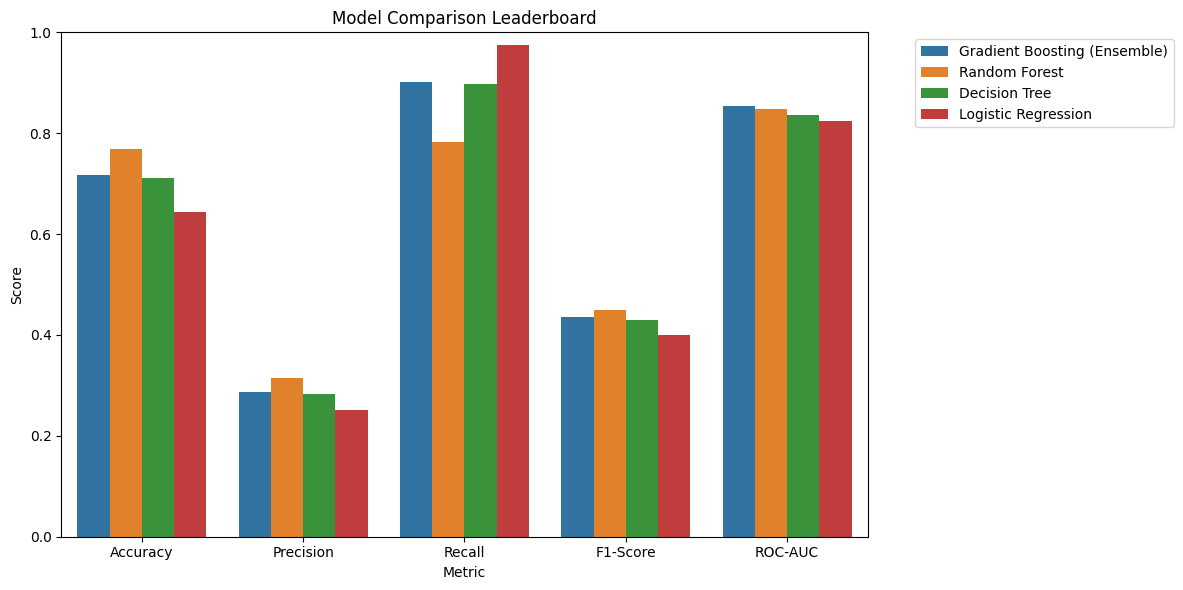

In [41]:
# CELL 10 — Leaderboard visualization
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_melted = results_df.melt(id_vars="Model", value_vars=metrics_to_plot,
                                   var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Model Comparison Leaderboard")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

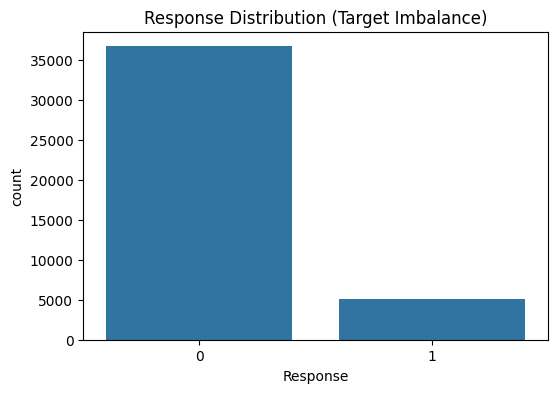

Response
0    87.741565
1    12.258435
Name: proportion, dtype: float64


In [42]:
# CELL — Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Response", data=train_df)
plt.title("Response Distribution (Target Imbalance)")
plt.show()

print(train_df["Response"].value_counts(normalize=True) * 100)

In [43]:
# CELL — Missing values
print("Train missing values:\n", train_df.isnull().sum())
print("\nTest missing values:\n", test_df.isnull().sum())

Train missing values:
 id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

Test missing values:
 id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                1
dtype: int64


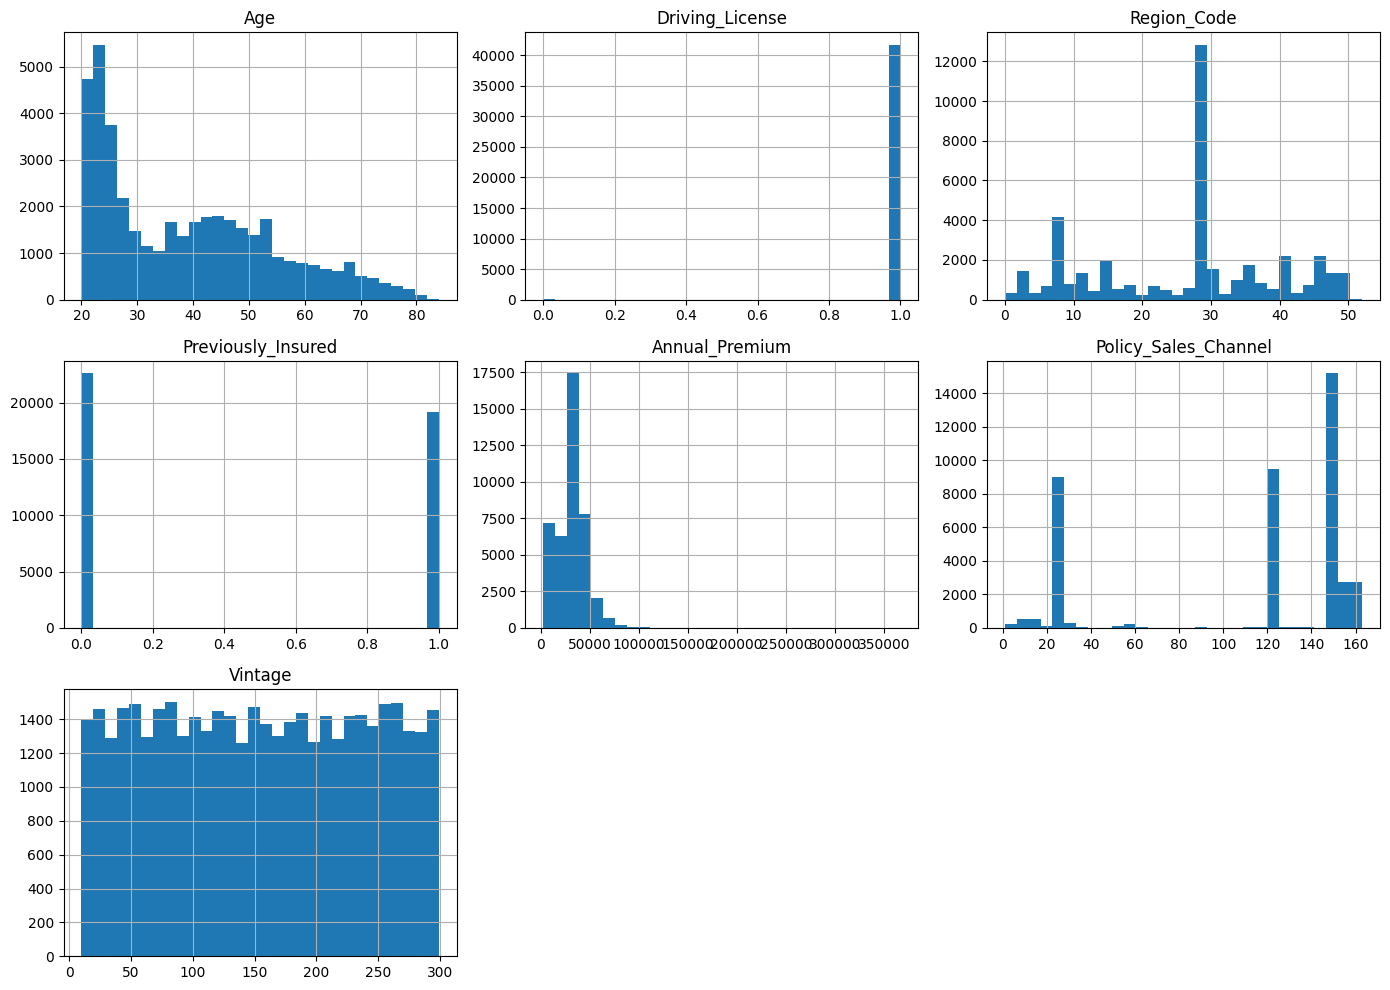

In [44]:
# CELL — Numeric distributions
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.drop(["id", "Response"])

train_df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

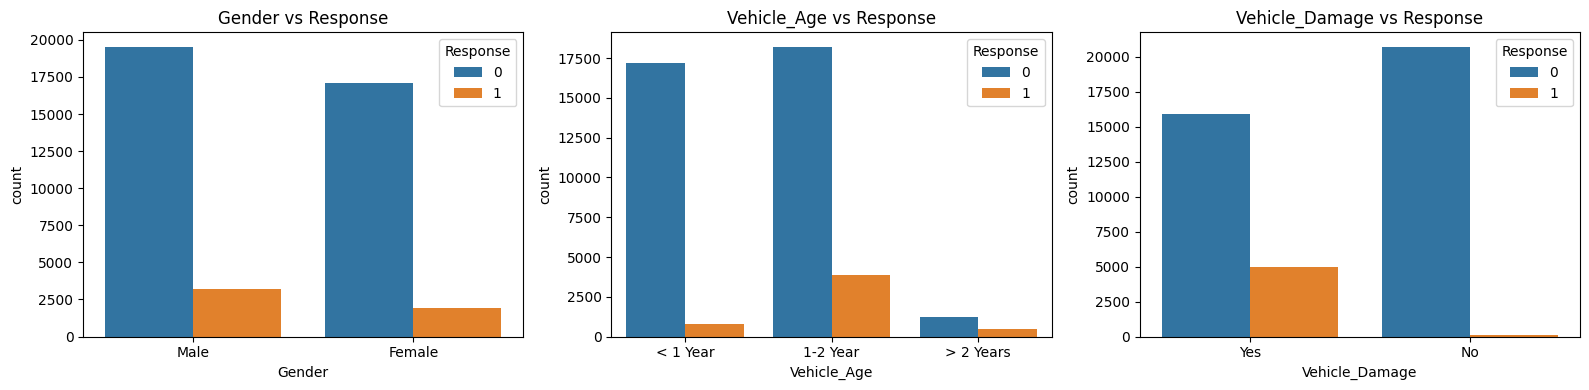

In [45]:
# CELL — Categorical vs target
cat_cols = ["Gender", "Vehicle_Age", "Vehicle_Damage"]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue="Response", data=train_df, ax=ax)
    ax.set_title(f"{col} vs Response")
plt.tight_layout()
plt.show()

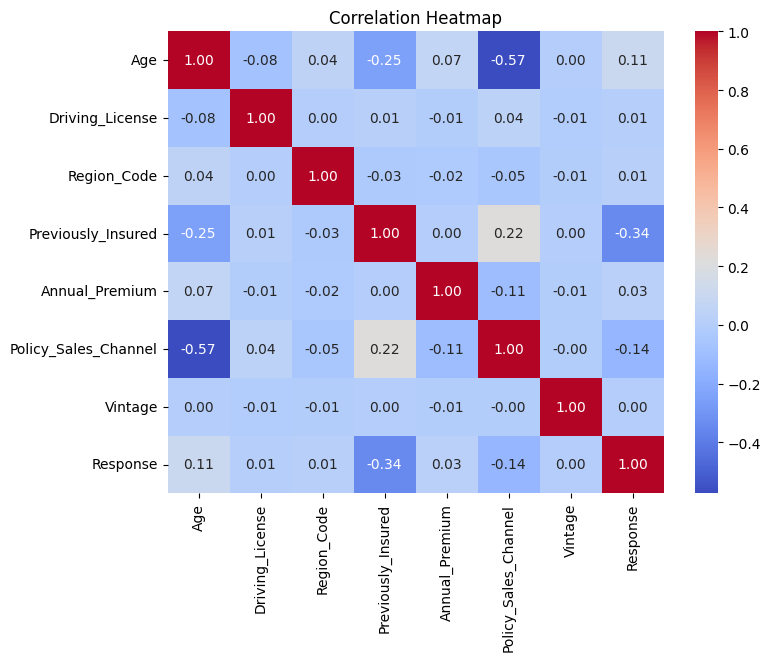

In [46]:
# CELL — Correlation heatmap
plt.figure(figsize=(8,6))
corr = train_df[numeric_cols.tolist() + ["Response"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()